# Notebook For Figure 2 Method Paper

### TODO 
- [X] Addd labels for group data. Carfull with A-E positions relative to the graphics ,,,,,
- [X] Make sure there is a bigger gap beteeen group statists and exemple mice data. Fr this yu can save a lot of space between the plot of the illustrtion animals 
- [ ] this line is still not clear to me: < session_index_offset = first_and_last_session_indexes[0] > Do we really need this ? 
-> TOM: We do. The learning curves need it. We can change it but it would take time, and I don't think it is very important compared to the rest
- [X] I think the learning curve function need to have as input the position of the legend
- [X] First line, rightmost panel. legend Rewarded TATs (median+quartile, n=19); Unrewarded TATs; Mouse 1 and mouse 2 
- [X] Second line, rightmost panel. legend just the black line 
- [X] Third line, rightmost panel. legend should be in a diffrent place
- [X] Between B and C modify legend of Unrewarded direction and Rewarded direction by Unrewarded direction (CW) and Rewarded direction (CCW).  Also start by rewarded (upper line).  
- [X] you use this trick to mkae sure that you use the same font and size across panels (something with RC)

In [1]:
# from IPython.display import display
# from PIL import Image

# # Load and display the image
# img = Image.open("Figure4.png")
# display(img)


# 1. Importing necessary libraries and general functions  

In [2]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import numpy as np
import pickle
import similaritymeasures as sm

plt.style.use('paper.mplstyle')



In [3]:
plotintermediatesteps = True 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

# path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/AurelienData/'
path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/MaudData/'

# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/AurelienData/'

# Analysing the entire group of mice
# mice_to_analyse = [
#     "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
#     "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_12", "MOURhoA_14",
#     "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_13", "MOUB6NN_15"
# ]

mice_to_analyse = ['MOU3974','MOU3975', 'MOU3987', 'MOU3988', 'MOU3991', 'MOU3992', 'MOU4551', 'MOU4552', 'MOU4560', 'MOU4561', 'MOU4562',
                   'MOU4563', 'MOU4623', 'MOU4964', 'MOU4965', 'MOU4986', 'MOU4987', 'MOU4988', 'MOU4993', 'MOU5007', 'MOU5008']

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes = [0,20]
# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set. TODO: Should reformulate this 
session_index_offset = first_and_last_session_indexes[0]

All mice folders are present in data folder.
 21 mice will be analysed



# 3. Chosing illustration mice and sessions  

In [5]:

# Set the limits of the x-axis on the statistics plots
xlim_stats = [first_and_last_session_indexes[0]+0.5,first_and_last_session_indexes[1]+0.5]

# 4. General functions

In [6]:
def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)

def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54
def compute_average_direction(points):

    """
    Compute the average direction of a trajectory portion, assuming the coordinates are in chronological order.

    Arguments:
        points (2D numpy.array): Trajectory of which the average direction will be computed

    Outputs:
        avg_diff (1D numpy.array): vector pointing to the average direction
        angle (float): angle of the vector with the x-axis 
    """
    
    diffs = np.diff(points, axis=0)
    avg_diff = np.mean(diffs, axis=0)
    angle = np.arctan2(avg_diff[1], avg_diff[0])
    return avg_diff, angle

def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index, start_session_index=0):
    
    """
    Determines the rewarded direction for the last session of a given mouse.
    In the protocol this notebook is used for, the rewarded direction of the 
    last session is the same as in all the sessions where rewarding is allowed. 
    
    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse sessions folders.
        session_index (int): Index of the session that will be used to define the rewarded direction
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list 

    Returns:
        str: 'CW' (Clockwise) if the rewarded direction is 270 degrees,
             'CCW' (Counterclockwise) if the rewarded direction is 90 degrees,
             numpy.nan if reward delivery is not allowed 
             None if an error occurs.
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[start_session_index:]

    # Load data from the last session
    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, sessions_to_process[start_session_index+session_index])

    # Extract rewarded direction in degrees
    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    # Check if reward delivery is allowed
    if session_param_df["allowRewardDelivery"][0]:

        # Determine the rewarded direction based on the extracted value
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'  # Clockwise

        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'  # Counterclockwise
            
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'  # Both directions

        else:
            print('ERROR: Unexpected unique rewarded direction value:', rewarded_direction_degrees)
            return None  # Explicitly return None to indicate failure
    
    else:

        # Rewarded direction is set to X if reward delivery os not allowed
        rewarded_direction = 'X'

    return rewarded_direction

def plot_learning_curve_alt_direction(mouse_metric_persession, ax, mice_list=None, start_session_index=0, mice_to_highlight=[], mice_to_highlight_labels=[None,None], show_individual_mice=True,
                         median_color='black', show_xlabel=True, ylabel='', main_line_label=None, 
                         tick_interval=1, index_offset=0, xlim=[None,None], ylim=None, show_background_legend=False, show_legend=True):
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves). Each session is color coded differently depending on
    it rewarding regime, and whether it happened it the morning or afternoon.

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool, optional): If true, plot a line for each individual mouse.
        session_limit (tuple, optional): Inrerval of session indexes to plot. Defaults to [None,None] (plot all sessions).
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_background_legend (bool, optional): Whether to show the legend of the session color codes. Defaults to False.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indexes = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    # Loop through each mouse and gather session data
    for mouse in mice_list:
        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indexes = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:
    
            if mouse in mice_to_highlight: # Plot the values in opac dark orange or green if the current mouse is in mice_to_highlight
                highlight_colors = ["darkorange", "green"]
                color_idx = mice_to_highlight.index(mouse) if mice_to_highlight.index(mouse) < len(highlight_colors) else 0
                ax.plot(session_indexes, values, color=highlight_colors[color_idx], marker='o', linewidth=0.5, 
                        markersize=1, label=mice_to_highlight_labels[mice_to_highlight.index(mouse)], zorder=100*len(median_color))
            else:
                ax.plot(session_indexes, values, marker='o', linewidth=0.5, markersize=1, alpha=0.3, markeredgewidth=0.0, color=median_color)

        # Update session index tracking
        all_session_indexes.update(session_indexes)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indexes)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # Find the first mouse of the sample. It will be used to determine the rewarded direction of the session
    folder_path_first_mouse = os.path.join(path_to_data_folder,list(mouse_metric_persession.keys())[0])

    # Initialize a set to contain colors that have already been shown in the legend
    used_colors = set([])

    # Iterate on the index of sessions
    for session_index in range(len(sorted_sessions)):
            
            # Fint the rewarded direction of the session
            rewarded_direction = finding_mouse_rewarded_direction(folder_path_first_mouse, session_index, start_session_index)

            # Checks if rewarding was available
            rewarding = rewarded_direction != 'X'

            # If there is no rewarding, color code the session in orange
            if not(rewarding):
                band_color = "orange"
                direction_label = "Familiarization" if show_background_legend else None

            # If both directions are rewarded, color code the session in purple
            elif rewarded_direction == "both":
                band_color = "#a875bc"
                direction_label = "Both rewarded directions" if show_background_legend else None

            # If the day is odd, color code the sessions in this day in blue
            elif session_index%4 < 2:
                band_color = "blue"
                direction_label = "CW rewarded direction" if show_background_legend else None

            # Else, color code them in red
            else:
                band_color = "red"
                direction_label = "CCW rewarded direction" if show_background_legend else None

            ax.axvspan(session_index+1 - 0.49, session_index+1 + 0.49, ymin=0.979, ymax=0.998,
                       color=band_color, zorder=3, clip_on=False, label = direction_label if not(band_color in used_colors) else None )

            # Add the color code to the used_colors set so that it will not appear several times on the legend
            used_colors.add(band_color)

            # Color the session in clear grey if it happened in afternoon, and light grey if it happened on morning
            if session_index % 2 != 0:  # Odd (PM sessions)
                
                vspan_color = "lightgrey"
                vspan_label = "Afternoon" if show_background_legend else None

                ax.axvspan(
                    session_index + 0.5, session_index + 1.5,
                    color="lightgrey", zorder=0, label = vspan_label if not(vspan_color in used_colors) else None,
                    lw=0
                )
                
            else:
                
                vspan_color = "darkgrey"
                vspan_label = "Morning" if show_background_legend else None

                ax.axvspan(
                    session_index + 0.5, session_index + 1.5,
                    color=vspan_color, zorder=0, label = vspan_label if not(vspan_color in used_colors) else None,
                    lw=0
                )

            used_colors.add(vspan_color)


    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_sessions)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1, color=median_color, linewidth = 1, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indexes:
        max_index = max(all_session_indexes)
        ax.set_xticks(range(1, max_index + 1, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    # Show legend if required
    if show_legend:

        if show_background_legend:
            # Organising background legend so that the Morning/Afternoon are shown first
            handles, labels = plt.gca().get_legend_handles_labels()
            current_order = list(range(len(handles)))
            target_order = current_order[1:3] + [current_order[0]] + current_order[3:]
            ax.legend([handles[idx] for idx in target_order],[labels[idx] for idx in target_order], frameon=False, loc=(0,1.05), ncol=2)

        else:
            ax.legend(frameon=False, loc=(0,1.05), ncol=2)

        


In [7]:
def order_runs(all_epochs):

    ordered_all_runs = []
    ordered_all_runs_frames = []

    for k in all_epochs.keys():

        if k != 'immobility':

            for i in range(len(all_epochs[k])):

                ordered_all_runs.append(all_epochs[k][i])
                ordered_all_runs_frames.append(all_epochs[k][i][0])

    ordered_all_runs_frames = sorted(ordered_all_runs_frames, key=lambda x: x[0])
    
    ordered_all_runs = sorted(ordered_all_runs,key=lambda x: x[0])

    return ordered_all_runs, ordered_all_runs_frames

def turns_by_visit_by_reward(all_epochs):

    visits = []

    n = -1

    runs_around_tower = all_epochs['run_around_tower']

    ordered_all_runs, ordered_all_runs_frames = order_runs(all_epochs)


    for run_around_tower in runs_around_tower:

        is_good_turn = run_around_tower[3]['Rewarded']
        max_rewards = run_around_tower[3]['max_rewards']
        # patch = run_around_tower[1][0]

        ordered_idx = ordered_all_runs_frames.index(run_around_tower[0])

        departure, arrival = [ordered_all_runs[ordered_idx-1][1][0],ordered_all_runs[ordered_idx-1][2][0]] if ordered_idx !=0 else ['','']

        is_previous_run_not_a_turn = (departure != arrival) or len(visits)==0

        if is_previous_run_not_a_turn:
        # if patch != previous_turn_patch:

            n = n + 1
            
            visits.append({})

            visits[n]['turns'] = 1
            visits[n]['rewarded_turns'] = int(is_good_turn)
            visits[n]['max_reward'] = max_rewards
            visits[n]['patch'] = run_around_tower[1][0] #patch
            visits[n]['visit_time'] = run_around_tower[4]['epoch_time']


        else:

            visits[n]['rewarded_turns'] += int(is_good_turn)
            visits[n]['turns'] += 1

        #previous_turn_patch = patch

    #print(visit)

    return visits

def compute_turns_per_rewarded_visit(folder_path_mouse_to_analyse, session_index):

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[session_index]

    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_analyse, session_index)
            
    # Load the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    #runs_around_towers = session_data['all_epochs']['run_around_tower']
        
    visit = turns_by_visit_by_reward(session_data['all_epochs'])
    
    # print(len(visit), ' number of visits')

    turns_per_visit = []
    rewarded_turns_per_visit = []
    visits_time = []
    max_rewards = []

    for i in range(len(visit)):

        if rewarded_direction=='X':

            nb_of_turns = visit[i]['turns']
            nb_of_rewarded_turns = np.nan # visit[i]['rewarded_turns']
            visit_time = visit[i]['visit_time']
            max_reward = np.nan # visit[i]['max_reward']


        else:
            
            nb_of_turns = visit[i]['turns']
            nb_of_rewarded_turns = visit[i]['rewarded_turns']
            visit_time = visit[i]['visit_time']
            max_reward = visit[i]['max_reward'] if visit[i]['max_reward']!=1 else np.nan

        turns_per_visit.append(nb_of_turns)
        rewarded_turns_per_visit.append(nb_of_rewarded_turns)
        visits_time.append(visit_time)
        max_rewards.append(max_reward)


    return [np.array(turns_per_visit),np.array(rewarded_turns_per_visit),np.array(visits_time),np.array(max_rewards)]



In [8]:
# Initialize the dictionary with empty lists for each mouse

mouse_median_turns_per_rewarded_visit = {mouse: [] for mouse in mice_to_analyse}

mouse_median_turns_vs_maxreward_per_rewarded_visit = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:
    
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)
    
    # Get the list of sessions
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_analyse)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_analyse, '\n')


    # analyse each session
    for session_index,session_to_analyse in enumerate(sessions_to_analyse):

        # Define the pickle file path
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)
                
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_analyse}, skipping .....')
            # Append session Nan data to the respective dictionaries
            mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nan])
            mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nan])

            continue  # Skip to the next session if the pickle file does not exist
        
        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        for n in range(len(session_data["all_epochs"]["run_around_tower"])):
    
            run = session_data["all_epochs"]["run_around_tower"][n]

        turns_per_visit,rewarded_turns_per_visit,visits_time,max_rewards = compute_turns_per_rewarded_visit(folder_path_mouse_to_analyse, session_index)
        unrewarded_turns_per_visit = turns_per_visit - rewarded_turns_per_visit
        

        #return [turns_per_visit,visits_time,max_rewards]

        turns_per_rewarded_visit = np.where(np.logical_not(np.equal(rewarded_turns_per_visit,0)),turns_per_visit,np.nan)
        turns_per_rewarded_visit = np.where(np.logical_not(np.isnan(rewarded_turns_per_visit)),turns_per_rewarded_visit,np.nan)
        turns_vs_maxreward_per_rewarded_visit = np.where(np.logical_not(np.equal(rewarded_turns_per_visit,0)),turns_per_visit-max_rewards,np.nan)

        mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
        mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])

Mouse MOU3974. There is/are 20 sessions:
['MOU3974_20230304-1314', 'MOU3974_20230305-1535', 'MOU3974_20230306-1211', 'MOU3974_20230306-1752', 'MOU3974_20230307-1231', 'MOU3974_20230307-1742', 'MOU3974_20230308-1150', 'MOU3974_20230308-1714', 'MOU3974_20230309-1155', 'MOU3974_20230309-1705', 'MOU3974_20230310-1220', 'MOU3974_20230310-1702', 'MOU3974_20230311-1258', 'MOU3974_20230311-1801', 'MOU3974_20230312-1145', 'MOU3974_20230312-1648', 'MOU3974_20230313-1129', 'MOU3974_20230313-1725', 'MOU3974_20230314-1036', 'MOU3974_20230314-1620'] 



/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(tur

Mouse MOU3975. There is/are 20 sessions:
['MOU3975_20230304-1329', 'MOU3975_20230305-1550', 'MOU3975_20230306-1228', 'MOU3975_20230306-1810', 'MOU3975_20230307-1249', 'MOU3975_20230307-1800', 'MOU3975_20230308-1206', 'MOU3975_20230308-1731', 'MOU3975_20230309-1209', 'MOU3975_20230309-1720', 'MOU3975_20230310-1234', 'MOU3975_20230310-1716', 'MOU3975_20230311-1311', 'MOU3975_20230311-1814', 'MOU3975_20230312-1158', 'MOU3975_20230312-1702', 'MOU3975_20230313-1145', 'MOU3975_20230313-1740', 'MOU3975_20230314-1050', 'MOU3975_20230314-1633'] 



/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(tur

Mouse MOU3987. There is/are 20 sessions:
['MOU3987_20230304-1237', 'MOU3987_20230305-1506', 'MOU3987_20230306-1132', 'MOU3987_20230306-1717', 'MOU3987_20230307-1157', 'MOU3987_20230307-1705', 'MOU3987_20230308-1114', 'MOU3987_20230308-1638', 'MOU3987_20230309-1126', 'MOU3987_20230309-1635', 'MOU3987_20230310-1150', 'MOU3987_20230310-1633', 'MOU3987_20230311-1230', 'MOU3987_20230311-1731', 'MOU3987_20230312-1116', 'MOU3987_20230312-1619', 'MOU3987_20230313-1101', 'MOU3987_20230313-1657', 'MOU3987_20230314-1002', 'MOU3987_20230314-1551'] 



...

/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(tur

Mouse MOU5007. There is/are 20 sessions:
['MOU5007_20250214-1101', 'MOU5007_20250214-1652', 'MOU5007_20250217-1207', 'MOU5007_20250217-1653', 'MOU5007_20250218-1135', 'MOU5007_20250218-1621', 'MOU5007_20250219-1112', 'MOU5007_20250219-1609', 'MOU5007_20250220-1118', 'MOU5007_20250220-1620', 'MOU5007_20250221-0939', 'MOU5007_20250221-1430', 'MOU5007_20250222-1049', 'MOU5007_20250222-1608', 'MOU5007_20250223-1123', 'MOU5007_20250223-1623', 'MOU5007_20250224-1236', 'MOU5007_20250224-1732', 'MOU5007_20250225-1217', 'MOU5007_20250225-1708'] 



/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(tur

Mouse MOU5008. There is/are 20 sessions:
['MOU5008_20250214-1120', 'MOU5008_20250214-1719', 'MOU5008_20250217-1228', 'MOU5008_20250217-1711', 'MOU5008_20250218-1149', 'MOU5008_20250218-1636', 'MOU5008_20250219-1128', 'MOU5008_20250219-1628', 'MOU5008_20250220-1132', 'MOU5008_20250220-1635', 'MOU5008_20250221-0954', 'MOU5008_20250221-1445', 'MOU5008_20250222-1105', 'MOU5008_20250222-1623', 'MOU5008_20250223-1138', 'MOU5008_20250223-1636', 'MOU5008_20250224-1250', 'MOU5008_20250224-1745', 'MOU5008_20250225-1231', 'MOU5008_20250225-1721'] 



/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:58: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(turns_vs_maxreward_per_rewarded_visit)])
/tmp/ipykernel_8282/152957974.py:59: RuntimeWarning: All-NaN slice encountered
  mouse_median_turns_vs_maxreward_per_rewarded_visit[mouse].append([session_index+1, np.nanmedian(tur

/tmp/ipykernel_8282/2731676171.py:186: RuntimeWarning: All-NaN slice encountered
  median_values.append(np.nanmedian(session_values))
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/tmp/ipykernel_8282/2731676171.py:186: RuntimeWarning: All-NaN slice encountered
  median_values.append(np.nanmedian(session_values))
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


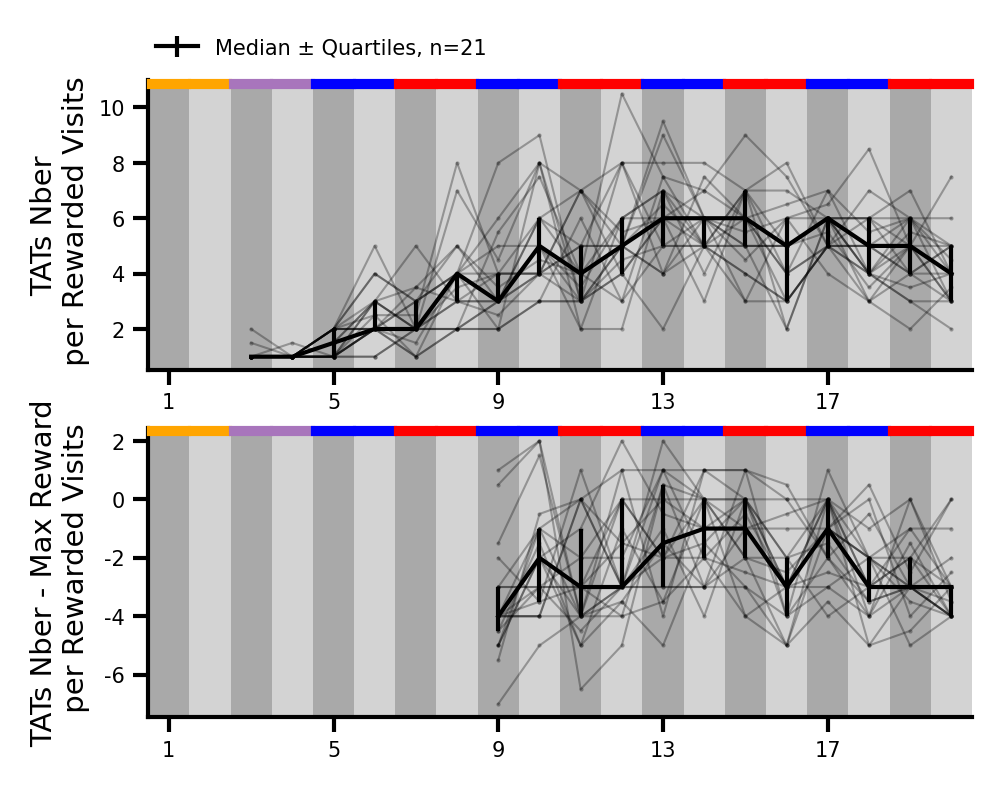

In [9]:
fig=plt.figure(figsize=(cm2inch(9), cm2inch(7)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(1, 1 , hspace=0.3)

tick_interval = 4

row1 = gs[0].subgridspec(2, 1)

ax_1 = plt.subplot(row1[0,0])
ax_2 = plt.subplot(row1[1,0])

plot_learning_curve_alt_direction(mouse_median_turns_per_rewarded_visit, ax_1, xlim=xlim_stats, ylabel='TATs Nber\n per Rewarded Visits', show_xlabel=False, tick_interval=tick_interval)

plot_learning_curve_alt_direction(mouse_median_turns_vs_maxreward_per_rewarded_visit, ax_2, ylabel='TATs Nber - Max Reward\n per Rewarded Visits', show_xlabel=False, show_legend=False, tick_interval=tick_interval, xlim=xlim_stats)

fig.align_ylabels()
